In [77]:
# import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [102]:
# read dataframe
df = pd.read_csv("Bengaluru_House_Data.csv")
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


# EDA

In [103]:
# Drop unwanted columns
cols = ['area_type', 'availability', 'society', 'balcony']
df = df.drop(columns= cols, axis = 1)
df

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00
...,...,...,...,...,...
13315,Whitefield,5 Bedroom,3453,4.0,231.00
13316,Richards Town,4 BHK,3600,5.0,400.00
13317,Raja Rajeshwari Nagar,2 BHK,1141,2.0,60.00
13318,Padmanabhanagar,4 BHK,4689,4.0,488.00


In [105]:
df.shape

(12438, 5)

In [104]:
df.drop_duplicates(inplace = True)

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13319 non-null  object 
 1   size        13304 non-null  object 
 2   total_sqft  13320 non-null  object 
 3   bath        13247 non-null  float64
 4   price       13320 non-null  float64
dtypes: float64(2), object(3)
memory usage: 520.4+ KB


In [106]:
# handling location column
# remove leading and trailing spaces
df['location'] = df['location'].str.strip()
# fill missing values
df['location'] = df['location'].fillna('Sarjapur Road')
# count frequency
loc = df['location'].value_counts()
# locations with <=10 occurrences
loc_lt_10 = loc[loc <= 10]
# replace them with "others"
df['location'] = df['location'].apply(lambda x: 'others' if x in loc_lt_10.index else x)
df['location'].value_counts()

location
others                  2928
Whitefield               508
Sarjapur  Road           364
Electronic City          275
Thanisandra              226
                        ... 
Tindlu                    11
Banashankari Stage V      11
Doddakallasandra          11
Thyagaraja Nagar          11
HAL 2nd Stage             11
Name: count, Length: 232, dtype: int64

In [107]:
#handling size column
df['size'].value_counts()
df['size'] = df['size'].fillna('2 BHK')
# extract only bhk number, and remove unwanted characters
df['size'] = df['size'].apply(lambda x: int(x.split()[0]))
df['size'].unique()
df.rename(columns = {'size': 'BHK'}, inplace = True)
df.head()

,location,BHK,total_sqft,bath,price
0,Electronic City Phase II,2,1056,2.0,39.07
1,Chikka Tirupathi,4,2600,5.0,120.00
2,Uttarahalli,3,1440,2.0,62.00
3,Lingadheeranahalli,3,1521,3.0,95.00
4,Kothanur,2,1200,2.0,51.00


In [99]:
df.isnull().sum()

location       0
BHK            0
total_sqft     0
bath          72
price          0
dtype: int64

In [ ]:
def clean_total_sqft(sqft):
    try:
        l = sqft.split("-")
        if len(l)==2:
            return (float(l[0]) + float(l[1]))/2
        else:
            return float(l[0])
    
    except:
        return None

df['total_sqft'] = df['total_sqft'].apply(clean_total_sqft)
df['total_sqft'].unique()

#handling nan values in total_sqft
df['total_sqft'] = df['total_sqft'].fillna(df['total_sqft'].mean()).round()
df['total_sqft'].value_counts()

total_sqft
1200.0    774
1100.0    203
1500.0    202
2400.0    194
600.0     177
         ... 
6688.0      1
2920.0      1
5666.0      1
7150.0      1
1557.0      1
Name: count, Length: 1891, dtype: int64

In [110]:
# handling bath
med = df['bath'].median()
df['bath'] = df['bath'].fillna(med)
df['bath'].unique()

array([ 2.,  5.,  3.,  4.,  6.,  1.,  9.,  8.,  7., 11., 10., 14., 27.,
       12., 16., 40., 15., 13., 18.])

## handling outliers

In [111]:
# create new col price_per_sqft
# price_per_sqft = price/total_sqft
# done to handle outliers
df['price_per_sqft'] = (df['price']*100000)/df['total_sqft']
df

,location,BHK,total_sqft,bath,price,price_per_sqft
0,Electronic City Phase II,2,1056.0,2.0,39.07,3699.810606
1,Chikka Tirupathi,4,2600.0,5.0,120.00,4615.384615
2,Uttarahalli,3,1440.0,2.0,62.00,4305.555556
3,Lingadheeranahalli,3,1521.0,3.0,95.00,6245.890861
4,Kothanur,2,1200.0,2.0,51.00,4250.000000
...,...,...,...,...,...,...
13314,Green Glen Layout,3,1715.0,3.0,112.00,6530.612245
13315,Whitefield,5,3453.0,4.0,231.00,6689.834926
13316,others,4,3600.0,5.0,400.00,11111.111111
13317,Raja Rajeshwari Nagar,2,1141.0,2.0,60.00,5258.545136


In [113]:
#handling outliers
#obsrvation: we have house les than 300 sqft those are outliers
#formula = total_sqft/bhk >= 300 --> keeps all real estate total sqfts

df = df[df['total_sqft']/df['BHK']>=300]
df.describe()

,BHK,total_sqft,bath,price,price_per_sqft
count,11705.000000,11705.000000,11705.000000,11705.000000,11705.000000
mean,2.666809,1614.028364,2.579667,114.455648,6405.096046
std,0.995743,1296.481668,1.099383,156.421987,4281.960980
min,1.000000,300.000000,1.000000,8.440000,267.829813
25%,2.000000,1120.000000,2.000000,50.000000,4253.521127
50%,3.000000,1314.000000,2.000000,71.000000,5348.837209
75%,3.000000,1720.000000,3.000000,120.000000,7000.000000
max,16.000000,52272.000000,16.000000,3600.000000,176470.588235


All unrealistic total_sqft less than 300 got removed

<Axes: xlabel='BHK'>

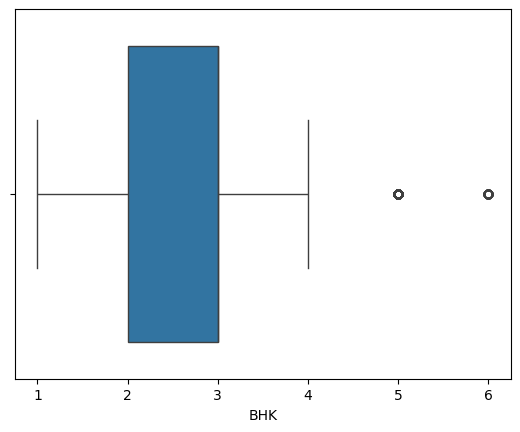

In [117]:
#handling outliers in BHK column
df['BHK'].unique()
df = df[df['BHK']<=6]
sns.boxplot(x = 'BHK', data = df)

In [125]:
#handling outliers in bath column
df[df['BHK']+2<df['bath']][['BHK', 'bath']]
#there are some extreme outliers that have bathrooms more than number of BHKs+2. these are outliers
df = df[(df['BHK']+2)>df['bath']] #removes outliers, by removing unrealistic values
df.head()

,location,BHK,total_sqft,bath,price,price_per_sqft
0,Electronic City Phase II,2,1056.0,2.0,39.07,3699.810606
1,Chikka Tirupathi,4,2600.0,5.0,120.00,4615.384615
2,Uttarahalli,3,1440.0,2.0,62.00,4305.555556
3,Lingadheeranahalli,3,1521.0,3.0,95.00,6245.890861
4,Kothanur,2,1200.0,2.0,51.00,4250.000000


<Axes: xlabel='price_per_sqft'>

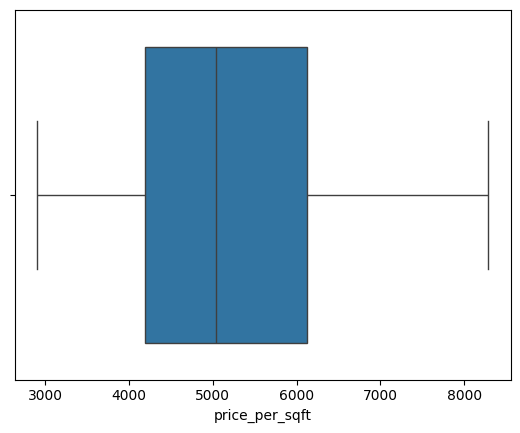

In [127]:
# handling outliers in price_per_sqft
# IQR
q1 = df['price_per_sqft'].quantile(0.25)
q3 = df['price_per_sqft'].quantile(0.75)

IQR = q3-q1

lower = q1 - 0.5*IQR
upper = q3 + 0.5*IQR
df = df[(df['price_per_sqft'] >= lower) & (df['price_per_sqft'] <= upper)]

sns.boxplot(x = 'price_per_sqft', data = df)

In [128]:
#removing price_per_sqft
df = df.drop('price_per_sqft', axis = 1)
df.head()

,location,BHK,total_sqft,bath,price
0,Electronic City Phase II,2,1056.0,2.0,39.07
1,Chikka Tirupathi,4,2600.0,5.0,120.00
2,Uttarahalli,3,1440.0,2.0,62.00
3,Lingadheeranahalli,3,1521.0,3.0,95.00
4,Kothanur,2,1200.0,2.0,51.00


In [130]:
# reset index

df.reset_index(inplace = True)
df = df.drop('index', axis = 1)
df

,location,BHK,total_sqft,bath,price
0,Electronic City Phase II,2,1056.0,2.0,39.07
1,Chikka Tirupathi,4,2600.0,5.0,120.00
2,Uttarahalli,3,1440.0,2.0,62.00
3,Lingadheeranahalli,3,1521.0,3.0,95.00
4,Kothanur,2,1200.0,2.0,51.00
...,...,...,...,...,...
9356,Rachenahalli,2,1050.0,2.0,52.71
9357,Bellandur,2,1262.0,2.0,47.00
9358,Green Glen Layout,3,1715.0,3.0,112.00
9359,Whitefield,5,3453.0,4.0,231.00


Text(0.5, 1.0, 'total_sqft vs price')

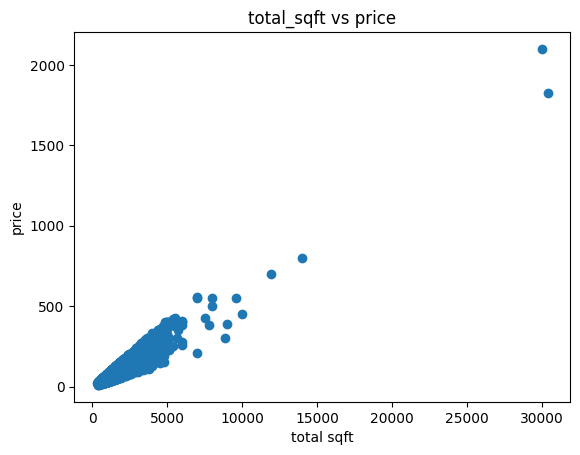

In [132]:
plt.scatter(df['total_sqft'], df['price'])
plt.xlabel("total sqft")
plt.ylabel("price")
plt.title("total_sqft vs price")

<Axes: >

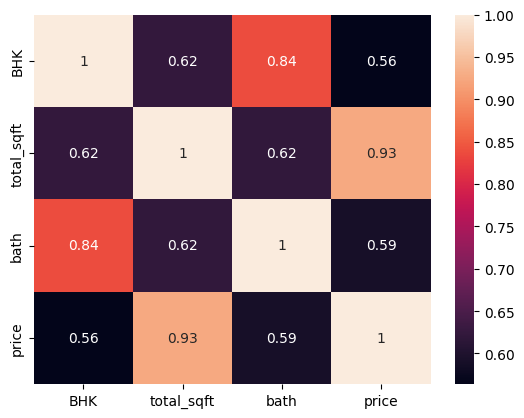

In [141]:
corr_data = df.iloc[:, 1:].corr()
corr_data
sns.heatmap(corr_data, annot = True)

## Model training

In [150]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [143]:
#encoding location column

encoder = LabelEncoder()
df['encoded_loc'] = encoder.fit_transform(df['location'])
df

,location,BHK,total_sqft,bath,price,encoded_loc
0,Electronic City Phase II,2,1056.0,2.0,39.07,75
1,Chikka Tirupathi,4,2600.0,5.0,120.00,57
2,Uttarahalli,3,1440.0,2.0,62.00,216
3,Lingadheeranahalli,3,1521.0,3.0,95.00,154
4,Kothanur,2,1200.0,2.0,51.00,146
...,...,...,...,...,...,...
9356,Rachenahalli,2,1050.0,2.0,52.71,183
9357,Bellandur,2,1262.0,2.0,47.00,40
9358,Green Glen Layout,3,1715.0,3.0,112.00,83
9359,Whitefield,5,3453.0,4.0,231.00,224


In [144]:
#divide data into input and output features
X = df.drop(["location", "price"], axis = 1)
y = df["price"]

In [145]:
# split data
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.3, random_state=42)

### Linear Regression

In [146]:
LR = LinearRegression()
LR.fit(Xtrain, ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [147]:
ypred = LR.predict(Xtest)
ypred

array([82.02259345, 62.36585654, 78.92844971, ..., 67.22008454,
       63.22808039, 66.58802221], shape=(2809,))

In [149]:
print("training eff: ", LR.score(Xtrain, ytrain))
print("testing eff: ", LR.score(Xtest, ytest))
print("R2 score:", r2_score(ytest, ypred))
print("MAE:", mean_absolute_error(ytest, ypred))

training eff:  0.8729438451219129
testing eff:  0.8119128738343321
R2 score: 0.8119128738343321
MAE: 14.795984637872946


### Decision Train Regressor

In [151]:
dt = DecisionTreeRegressor()
dt.fit(Xtrain, ytrain)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [152]:
ypred = dt.predict(Xtest)
ypred

array([123.  ,  44.  ,  68.  , ...,  58.17,  50.  ,  95.  ], shape=(2809,))

In [153]:
print("training eff: ", dt.score(Xtrain, ytrain))
print("testing eff: ", dt.score(Xtest, ytest))
print("R2 score:", r2_score(ytest, ypred))
print("MAE:", mean_absolute_error(ytest, ypred))

training eff:  0.9910812173913075
testing eff:  0.7144779638581565
R2 score: 0.7144779638581565
MAE: 15.734679928580205


with this, we can save files as 

## Model serialization

In [154]:
# saving training model
# skips the continuous training process

#done by using pickle model

import pickle
with open("Linear_model.pkl", "wb") as file:
    pickle.dump(LR, file)

In [ ]:
#using joblib

# import joblib
# file = "model.pkl"
# joblib.dump(LR, file)

['model.pkl']

## Encoder Serialization

In [156]:
with open("labelencoder.pkl", "wb") as file:
    pickle.dump(encoder, file)

In [158]:
df.to_csv("cleaned_bengaluru.csv")